# ТЗ
Реализация стохастических градиентных методов с $AdaGrad$ и $AdamW$.
Подходы к борьбе с переобучением:
- Отложенная выборка (Hold-out Validation): Техника однократного разбиения исходного множества на изолированные подмножества. Если тестовое подмножество используется исключительно для финальной фиксации метрик качества, процедура корректна. Если же по отложенной выборке подбираются гиперпараметры ($\lambda$) или принимается решение о досрочной остановке (Early Stopping), для предотвращения утечки данных (data leakage) обычно применяется трехкомпонентное разбиение: Train (настройка весов), Validation (оптимизация $\lambda$, Early Stopping) и Test.
  
- L1-регуляризация (аппроксимация Lasso штрафа): шаг обновления весов разделяется на 2 этапа:
- - Градиентный шаг по функции MSE:
$$\tilde{w}_{t+1} = w_t - \eta \nabla J_{MSE}(w_t)$$
- - Применение оператора мягкого порога (Soft-Thresholding):
$$w_{t+1} = \text{sign}(\tilde{w}_{t+1}) \cdot \max\left(\vert{}\tilde{w}_{t+1}\vert{} - \eta \lambda, \, 0\right)$$

- L2-регуляризация (Ridge-штраф):
  $$J_{L2} = \frac{1}{B} \sum_{i=1}^B (y_i - \hat{y}_i)^2 + \frac{\lambda}{2} \sum_{j=1}^M w_j^2$$

где $B$ - размер текущего батча, $M$ - количество признаков, а вектор весов $w$ не включает в себя свободный член (bias).

*Дополнительные разъяснения:* 
- AdaGrad + L2: штраф добавляется в градиент $\nabla J = \nabla J_{MSE} + \lambda w$. В результате L2-градиент попадает в аккумулятор $G_t = G_{t-1} + (\nabla J)^2$, что ускоряет затухание темпа обучения.

- AdamW + Weight Decay: L2-штраф применяется как независимое сжатие весов $w_{t+1} = w_t (1 - \eta \lambda) - \text{Adam}(\nabla J_{MSE})$, минуя накопители моментов $m_t$ и $v_t$.

## *AdaGrad* (Adaptive Gradient Algorithm)
- Суть: Алгоритм адаптирует темп обучения покоординатно, масштабируя текущий градиент обратно пропорционально корню из суммы квадратов всех исторических градиентов данного параметра. Это позволяет делать большие шаги по редким (разреженным) признакам и уменьшать шаг по часто обновляемым.

Математический шаг оптимизации:
Пусть $g_t = \nabla_{\theta} L(\theta_t)$ - градиент функции потерь по весам $\theta$ на шаге $t$. Аккумуляция квадратов градиентов $G_t \in \mathbb{R}^d$ и обновление параметров выполняются покоординатно (оператор $\odot$ обозначает умножение Адамара):
$$ G_t = G_{t-1} + g_t \odot g_t $$
$$ \theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{G_t} + \epsilon} \odot g_t $$
Где $\eta$ - базовый темп обучения, а $\epsilon > 0$ - сглаживающий параметр, предотвращающий деление на ноль (в реализации torch.optim.Adagrad по умолчанию $\epsilon = 10^{-10}$). Монотонное возрастание компонент вектора $G_t$ гарантирует монотонное убывание эффективного шага.

## AdamW (Adam with Decoupled Weight Decay)
- Суть: модификация классического алгоритма Adam, которая изолирует (расцепляет) механизм регуляризации от процесса адаптации темпа обучения. Adam комбинирует идеи накопления импульса (Momentum) и покоординатного масштабирования шага (RMSProp), вычисляя экспоненциально затухающие средние прошлых градиентов ($m_t$) и их квадратов ($v_t$). В отличие от Adam, где L2-штраф модифицирует градиент, AdamW выполняет спад весов (Weight Decay) напрямую на этапе обновления параметров.

Математический шаг оптимизации: Пусть $g_t = \nabla_{\theta} L_{MSE}(\theta_t)$ - градиент функции потерь по весам $\theta$ на шаге $t$, рассчитанный без учета регуляризационных штрафов.
Вычисление смещенных оценок первого (усредненный градиент) и второго (нецентрированная дисперсия) моментов:
$$m_t = \beta_1 m_{t-1} + (1 - \beta_1) g_t$$
$$v_t = \beta_2 v_{t-1} + (1 - \beta_2) g_t \odot g_t$$
Коррекция смещения моментов для компенсации инициализации нулями ($m_0 = 0, v_0 = 0$):
$$\hat{m}_t = \frac{m_t}{1 - \beta_1^t}, \quad \hat{v}_t = \frac{v_t}{1 - \beta_2^t}$$
Модификация шага параметров и финальное обновление (механизм Decoupled Weight Decay):
$$\theta_{t+1} = \theta_t \cdot (1 - \eta \lambda) - \frac{\eta}{\sqrt{\hat{v}_t} + \epsilon} \odot \hat{m}_t$$

где:
$\eta$ - базовый темп обучения (lr);
$\lambda$ - коэффициент спада весов (weight_decay);
$\beta_1, \beta_2$ - коэффициенты затухания моментов (канонические значения: $\beta_1=0.9, \beta_2=0.999$);
$\epsilon$ - сглаживающий параметр для численной стабильности (в torch.optim.AdamW по умолчанию $\epsilon = 10^{-8}$).

- Отличие от классического Adam: если в обычном Adam использовать параметр weight_decay, алгоритм преобразует градиент: $g^{new}_t = g_t + \lambda \theta_t$. В этом случае штраф "подмешивается" в моменты $m_t$ и $v_t$. Из-за деления на $\sqrt{v_t}$ в адаптивном шаге веса, которые исторически имели большие градиенты, будут штрафоваться меньше, чем веса с маленькими градиентами. AdamW решает данную проблему, выполняя линейный спад веса $\theta_t \cdot (1 - \eta \lambda)$ независимо от накопленной динамики градиентов.

# Импорт библиотек, датасета, hold-out validation

In [1]:
import copy
import itertools
import sys
import time
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge, HuberRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import lightgbm as lgb
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from sklearn.ensemble import IsolationForest

In [2]:
class NumPyScaler:
    def __init__(self):
        self.mean = None
        self.std = None

    def fit(self, X):
        self.mean = np.mean(X, axis=0)
        self.std = np.std(X, axis=0)
        self.std[self.std == 0] = 1e-8 
        return self

    def transform(self, X):
        return (X - self.mean) / self.std

    def fit_transform(self, X):
        return self.fit(X).transform(X)

    def inverse_transform(self, X):
        return X * self.std + self.mean

In [3]:
class NumPyRobustScaler:
    def __init__(self):
        self.median = None
        self.iqr = None

    def fit(self, X):
        self.median = np.median(X, axis=0)
        q75, q25 = np.percentile(X, [75, 25], axis=0)
        self.iqr = q75 - q25
        self.iqr[self.iqr == 0] = 1e-8
        return self

    def transform(self, X):
        return (X - self.median) / self.iqr

    def fit_transform(self, X):
        return self.fit(X).transform(X)

In [4]:
class CustomLinearRegressionSGD:
    def __init__(
        self, 
        optimizer="adamw",
        learning_rate=0.01,
        reg_type="none",
        lmbda=0.0,
        batch_size=64,
        epochs=300,
        beta1=0.9,
        beta2=0.999,
        epsilon=1e-8,
        seed=42
    ):
        self.optimizer = optimizer.lower()
        self.lr = learning_rate
        self.reg_type = reg_type.lower()
        self.lmbda = lmbda
        self.batch_size = batch_size
        self.epochs = epochs
        self.beta1 = beta1
        self.beta2 = beta2
        self.epsilon = epsilon
        self.seed = seed

        self.w = None
        self.b = 0.0

        self.G_w = None
        self.G_b = 0.0
        self.m_w, self.v_w = None, None
        self.m_b, self.v_b = 0.0, 0.0
        self.t = 0

        self.history = {
            "train": [],
            "val": [],
            "test": [],
            "weight_trajectories": [] 
        }

    def _soft_thresholding(self, w, threshold):
        return np.sign(w) * np.maximum(np.abs(w) - threshold, 0.0)

    def fit(self, X_train, y_train, X_val=None, y_val=None, X_test=None, y_test=None):
        np.random.seed(self.seed)
        n_samples, n_features = X_train.shape

        self.w = np.zeros(n_features)
        self.b = 0.0

        if self.optimizer == "adagrad":
            self.G_w = np.zeros(n_features)
            self.G_b = 0.0
        elif self.optimizer == "adamw":
            self.m_w = np.zeros(n_features)
            self.v_w = np.zeros(n_features)
            self.m_b, self.v_b = 0.0, 0.0

        for epoch in range(1, self.epochs + 1):
            indices = np.random.permutation(n_samples)
            X_shuffled = X_train[indices]
            y_shuffled = y_train[indices]

            for start_idx in range(0, n_samples, self.batch_size):
                self.t += 1
                end_idx = start_idx + self.batch_size
                X_batch = X_shuffled[start_idx:end_idx]
                y_batch = y_shuffled[start_idx:end_idx]
                B = X_batch.shape[0]

                preds = np.dot(X_batch, self.w) + self.b
                err = preds - y_batch
                grad_w = (2 / B) * np.dot(X_batch.T, err)
                grad_b = (2 / B) * np.sum(err)

                if self.optimizer == "adagrad":
                    if self.reg_type == "l2":
                        grad_w += self.lmbda * self.w

                    self.G_w += grad_w ** 2
                    self.G_b += grad_b ** 2

                    step_w = self.lr / (np.sqrt(self.G_w) + self.epsilon)
                    step_b = self.lr / (np.sqrt(self.G_b) + self.epsilon)

                    self.w -= step_w * grad_w
                    self.b -= step_b * grad_b

                    if self.reg_type == "l1":
                        self.w = self._soft_thresholding(self.w, step_w * self.lmbda)

                elif self.optimizer == "adamw":
                    self.m_w = self.beta1 * self.m_w + (1 - self.beta1) * grad_w
                    self.v_w = self.beta2 * self.v_w + (1 - self.beta2) * (grad_w ** 2)

                    m_w_hat = self.m_w / (1 - self.beta1 ** self.t)
                    v_w_hat = self.v_w / (1 - self.beta2 ** self.t)

                    step_w = self.lr / (np.sqrt(v_w_hat) + self.epsilon)

                    if self.reg_type == "l2":
                        self.w -= self.lr * self.lmbda * self.w

                    self.w -= step_w * m_w_hat

                    if self.reg_type == "l1":
                        self.w = self._soft_thresholding(self.w, step_w * self.lmbda)

                    self.m_b = self.beta1 * self.m_b + (1 - self.beta1) * grad_b
                    self.v_b = self.beta2 * self.v_b + (1 - self.beta2) * (grad_b ** 2)
                    m_b_hat = self.m_b / (1 - self.beta1 ** self.t)
                    v_b_hat = self.v_b / (1 - self.beta2 ** self.t)
                    self.b -= (self.lr / (np.sqrt(v_b_hat) + self.epsilon)) * m_b_hat

            self.history["train"].append(np.mean((self.predict(X_train) - y_train) ** 2))
            if X_val is not None and y_val is not None:
                self.history["val"].append(np.mean((self.predict(X_val) - y_val) ** 2))
            if X_test is not None and y_test is not None:
                self.history["test"].append(np.mean((self.predict(X_test) - y_test) ** 2))
            self.history["weight_trajectories"].append(self.w.copy())

        return self

    def predict(self, X):
        return np.dot(X, self.w) + self.b

In [5]:
def sample_hyperparameters(n_trials):
    trials = []
    for opt in CONFIG["OPTIMIZERS"]:
        for reg in CONFIG["REG_TYPES"]:
            current_trials = 5 if reg == "None" else n_trials
            for _ in range(current_trials):
                lr = 10 ** np.random.uniform(-4, -1)
                
                if reg == "None":
                    lmbda = 0.0
                else:
                    lmbda = 10 ** np.random.uniform(-5, 1)
                trials.append({
                    "opt": opt, 
                    "reg": reg, 
                    "lr": lr, 
                    "lambda": lmbda
                })
    return trials

# Обучение моделей, подбор параметров

In [6]:
# Находим нужный сэмплированный датасет
target_relative_path = Path("..") / "Dataset (Farhat)" / "dataset_sample_all.csv"
dataset_path = target_relative_path.resolve()

if not dataset_path.exists():
    raise FileNotFoundError(f"ОШИБКА: файл датасета не найден по пути: {dataset_path}")
print(f"Успешно обнаружен файл датасета по пути: {dataset_path}")

Успешно обнаружен файл датасета по пути: /Users/test/Desktop/Various_Linear_Regression_Factors/Dataset (Farhat)/dataset_sample_all.csv


In [7]:
CONFIG = {
    "SEED": 67,
    "EPOCHS": 500,                       
    "N_TRIALS": 100,
    "BATCH_SIZE": 64,                      
    "REG_TYPES": ["l1", "l2", "None"],
    "OPTIMIZERS": ["AdaGrad", "AdamW"],
}
sns.set_theme(style="whitegrid")

In [8]:
np.random.seed(CONFIG["SEED"])
df = pd.read_csv(dataset_path)
target_name = "Log_Цена"
X_raw = df.drop(columns=[target_name]).values
y_raw = df[target_name].values.reshape(-1, 1)
n_samples = len(X_raw)

shuffled_indices = np.random.permutation(n_samples)
train_end = int(0.6 * n_samples)
val_end = int(0.8 * n_samples)

train_idx = shuffled_indices[:train_end]
val_idx = shuffled_indices[train_end:val_end]
test_idx = shuffled_indices[val_end:]

X_train_raw, y_train_raw = X_raw[train_idx], y_raw[train_idx].flatten()
X_val_raw, y_val_raw = X_raw[val_idx], y_raw[val_idx].flatten()
X_test_raw, y_test_raw = X_raw[test_idx], y_raw[test_idx].flatten()

scaler_X = NumPyScaler().fit(X_train_raw)
X_train = scaler_X.transform(X_train_raw)
X_val = scaler_X.transform(X_val_raw)
X_test = scaler_X.transform(X_test_raw)

scaler_y = NumPyScaler().fit(y_train_raw.reshape(-1, 1))
y_train = scaler_y.transform(y_train_raw.reshape(-1, 1)).flatten()
y_val = scaler_y.transform(y_val_raw.reshape(-1, 1)).flatten()
y_test = scaler_y.transform(y_test_raw.reshape(-1, 1)).flatten()

In [9]:
# # Удаление выбросов через Isolation Forest
# iso = IsolationForest(contamination=0.01, random_state=CONFIG["SEED"])
# outlier_mask = iso.fit_predict(X_train_raw) != -1

# X_train_clean = X_train_raw[outlier_mask]
# y_train_clean = y_train_raw[outlier_mask]

# # Робастная стандартизация
# robust_scaler_x = NumPyRobustScaler().fit(X_train_clean)
# X_train = robust_scaler_x.transform(X_train_clean)
# X_val = robust_scaler_x.transform(X_val_raw)
# X_test = robust_scaler_x.transform(X_test_raw)

# robust_scaler_y = NumPyRobustScaler().fit(y_train_clean.reshape(-1, 1))
# y_train = robust_scaler_y.transform(y_train_clean.reshape(-1, 1)).ravel()
# y_val = robust_scaler_y.transform(y_val_raw.reshape(-1, 1)).ravel()
# y_test = robust_scaler_y.transform(y_test_raw.reshape(-1, 1)).ravel()

In [10]:
history_data = {}
all_experiments = []
configurations = sample_hyperparameters(CONFIG["N_TRIALS"])
for config in tqdm(configurations, desc="Random Search Progress"):
    opt_name = config["opt"]
    reg_type = config["reg"]
    learning_rate = config["lr"]
    lmbda = config["lambda"]

    start_time = time.time()
    model = CustomLinearRegressionSGD(
        optimizer=opt_name,
        learning_rate=learning_rate,
        reg_type=reg_type,
        lmbda=lmbda,
        batch_size=CONFIG["BATCH_SIZE"],
        epochs=CONFIG["EPOCHS"],
        seed=CONFIG["SEED"]
    )
    model.fit(X_train, y_train, X_val, y_val, X_test, y_test)
    elapsed_time = time.time() - start_time

    val_losses = model.history["val"]
    best_epoch_idx = int(np.argmin(val_losses))
    best_val_mse = val_losses[best_epoch_idx]
    
    best_test_mse_at_best_val = model.history["test"][best_epoch_idx]
    
    n_features = X_train.shape[1]
    zero_weights = np.sum(np.abs(model.w) == 0.0)
    sparsity = (zero_weights / n_features) * 100.0

    if reg_type == "None":
        exp_key = f"{opt_name}_None_lr_{learning_rate:.6f}"
    else:
        exp_key = f"{opt_name}_{reg_type}_lr_{learning_rate:.6f}_lambda_{lmbda:.6f}"

    history_data[exp_key] = {
        "train": model.history["train"],
        "val": model.history["val"],
        "test": model.history["test"],
        "final_test": model.history["test"][-1],
        "best_test_mse_at_best_val": best_test_mse_at_best_val,
        "time": elapsed_time,
        "best_val_mse": best_val_mse,
        "best_epoch": best_epoch_idx + 1,
        "final_weights": model.w.copy(),
        "weight_trajectories": np.array(model.history["weight_trajectories"]),
        "sparsity": sparsity,
        "lr": learning_rate,
        "opt": opt_name,
        "reg": reg_type,
        "lmbda": lmbda
    }

    all_experiments.append({
        "exp_key": exp_key,
        "opt": opt_name,
        "reg": reg_type,
        "lr": learning_rate,
        "lambda": lmbda,
        "best_val_mse": best_val_mse,
        "best_test_mse": best_test_mse_at_best_val,
        "final_test_mse": model.history["test"][-1],
        "sparsity_%": sparsity,
        "time_sec": elapsed_time
    })

df_results = pd.DataFrame(all_experiments).sort_values("best_val_mse").reset_index(drop=True)
print(f"Завершено {len(df_results)} экспериментов.\nЛучшие модели:")
display(df_results.head(5))

Random Search Progress:   0%|          | 0/410 [00:00<?, ?it/s]

Завершено 410 экспериментов.
Лучшие модели:


,exp_key,opt,reg,lr,lambda,best_val_mse,best_test_mse,final_test_mse,sparsity_%,time_sec
0,AdamW_l2_lr_0.001907_lambda_0.000955,AdamW,l2,0.001907,0.000955,0.156357,0.180442,0.180244,0.0,0.750713
1,AdamW_l1_lr_0.001931_lambda_0.000085,AdamW,l1,0.001931,0.000085,0.156362,0.180453,0.180263,0.0,0.815441
2,AdamW_l2_lr_0.002452_lambda_0.000133,AdamW,l2,0.002452,0.000133,0.156371,0.180672,0.180502,0.0,0.767499
3,AdamW_l2_lr_0.001846_lambda_0.038396,AdamW,l2,0.001846,0.038396,0.156373,0.180470,0.180277,0.0,0.764757
4,AdamW_l2_lr_0.002486_lambda_0.000049,AdamW,l2,0.002486,0.000049,0.156375,0.180684,0.180515,0.0,0.778173


# Построение baselines 

## Обычное Среднее + МНК (без, с L1, L2 регуляризациями)

In [11]:
y_tr_1d = y_train.ravel()
y_te_1d = y_test.ravel()

# Baseline Mean
mean_pred = np.full_like(y_te_1d, np.mean(y_tr_1d))
history_data["Baseline_Mean"] = {
    "final_test": mean_squared_error(y_te_1d, mean_pred),
    "r2_test": r2_score(y_te_1d, mean_pred)
}

# МНК без регуляризации (OLS Pure)
ols_pure = LinearRegression().fit(X_train, y_tr_1d)
ols_preds = ols_pure.predict(X_test)
history_data["Baseline_OLS_Pure"] = {
    "final_test": mean_squared_error(y_te_1d, ols_preds),
    "r2_test": r2_score(y_te_1d, ols_preds)
}

# Робастный бейзлайн (Huber)
huber = HuberRegressor(max_iter=2000).fit(X_train, y_tr_1d)
huber_preds = huber.predict(X_test)
history_data["Baseline_Huber"] = {
    "final_test": mean_squared_error(y_te_1d, huber_preds),
    "r2_test": r2_score(y_te_1d, huber_preds)
}

# LightGBM
lgb_model = lgb.LGBMRegressor(
    random_state=CONFIG["SEED"], 
    n_jobs=1, 
    verbose=-1,
    n_estimators=100
).fit(X_train, y_tr_1d)

lgb_preds = lgb_model.predict(X_test)
history_data["Baseline_LightGBM"] = {
    "final_test": mean_squared_error(y_te_1d, lgb_preds),
    "r2_test": r2_score(y_te_1d, lgb_preds)
}

# OLS с L1 (Lasso) и L2 (Ridge)
for lmbda in [0.0001, 0.001, 0.01, 0.1, 1.0]:
    # Lasso (L1)
    lasso = Lasso(alpha=lmbda, max_iter=20000).fit(X_train, y_tr_1d)
    lasso_preds = lasso.predict(X_test)
    history_data[f"Baseline_OLS_L1_lambda_{lmbda:.6f}"] = {
        "final_test": mean_squared_error(y_te_1d, lasso_preds),
        "r2_test": r2_score(y_te_1d, lasso_preds)
    }
    
    # Ridge (L2)
    ridge = Ridge(alpha=lmbda).fit(X_train, y_tr_1d)
    ridge_preds = ridge.predict(X_test)
    history_data[f"Baseline_OLS_L2_lambda_{lmbda:.6f}"] = {
        "final_test": mean_squared_error(y_te_1d, ridge_preds),
        "r2_test": r2_score(y_te_1d, ridge_preds)
    }

# Графики

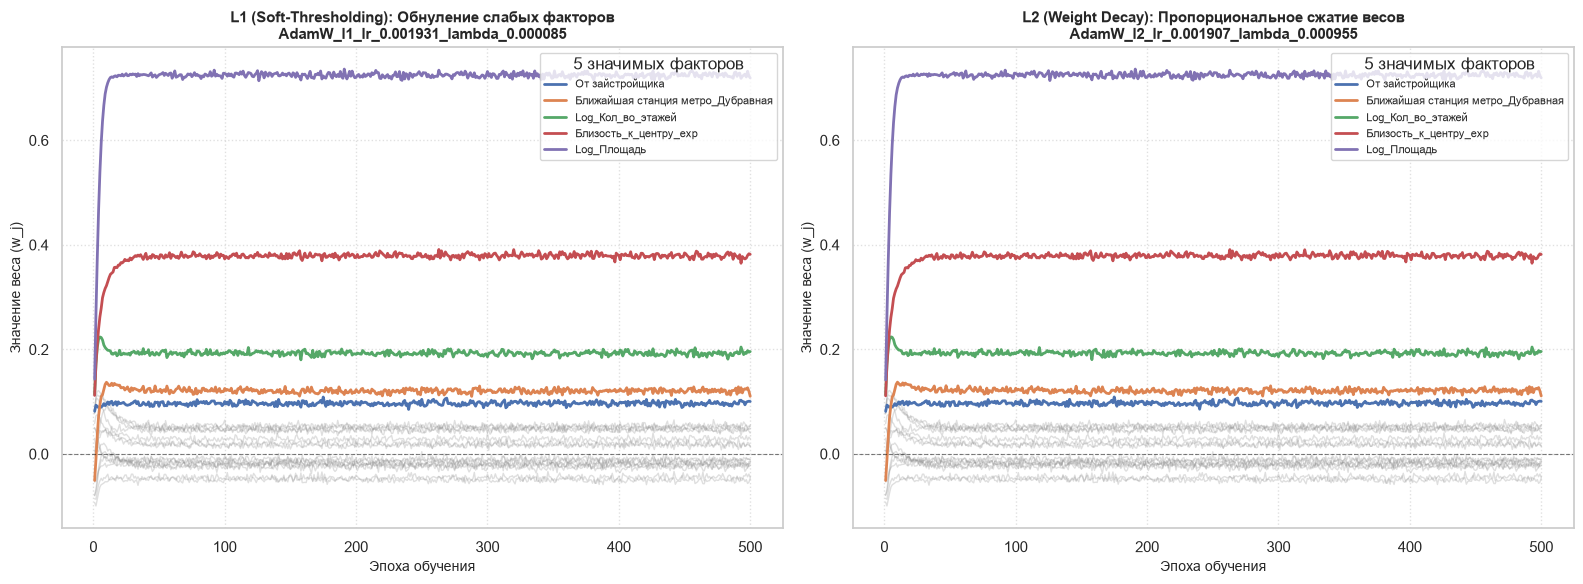

In [12]:
def plot_weight_trajectories_annotated(history_data, exp_key_l1, exp_key_l2, feature_names=None):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    for idx, (exp_key, title) in enumerate([
        (exp_key_l1, "L1 (Soft-Thresholding): Обнуление слабых факторов"),
        (exp_key_l2, "L2 (Weight Decay): Пропорциональное сжатие весов")
    ]):
        ax = axes[idx]
        weights = history_data[exp_key]["weight_trajectories"]  
        epochs = np.arange(1, weights.shape[0] + 1)
        num_features = weights.shape[1]
        
        if feature_names is None or len(feature_names) != num_features:
            names = [f"x_{i}" for i in range(num_features)]
        else:
            names = list(feature_names)
            
        final_abs_weights = np.abs(weights[-1, :])
        top_5_idx = np.argsort(final_abs_weights)[-5:]
        
        for j in range(num_features):
            if j not in top_5_idx:
                ax.plot(epochs, weights[:, j], color="gray", alpha=0.25, linewidth=1)
                
        for j in top_5_idx:
            ax.plot(epochs, weights[:, j], label=names[j], linewidth=2)
            
        ax.axhline(0, color="black", linestyle="--", alpha=0.5, linewidth=0.8)
        ax.set_title(f"{title}\n{exp_key}", fontsize=11, fontweight="bold")
        ax.set_xlabel("Эпоха обучения", fontsize=10)
        ax.set_ylabel("Значение веса (w_j)", fontsize=10)
        ax.grid(True, linestyle=":", alpha=0.6)
        ax.legend(title="5 значимых факторов", loc="upper right", fontsize=8)

    plt.tight_layout()
    plt.savefig("IMG/weight_trajectories_annotated.png", bbox_inches="tight")
    plt.show()


l1_keys = [
    k for k, v in history_data.items() 
    if isinstance(v, dict) and str(v.get("reg", "")).upper() == "L1" and "weight_trajectories" in v
]
l2_keys = [
    k for k, v in history_data.items() 
    if isinstance(v, dict) and str(v.get("reg", "")).upper() == "L2" and "weight_trajectories" in v
]
best_l1_key = min(l1_keys, key=lambda k: history_data[k].get("best_val_mse", float("inf")))
best_l2_key = min(l2_keys, key=lambda k: history_data[k].get("best_val_mse", float("inf")))
plot_weight_trajectories_annotated(history_data, exp_key_l1=best_l1_key, exp_key_l2=best_l2_key, feature_names=df.drop(columns=[target_name]).columns.tolist())

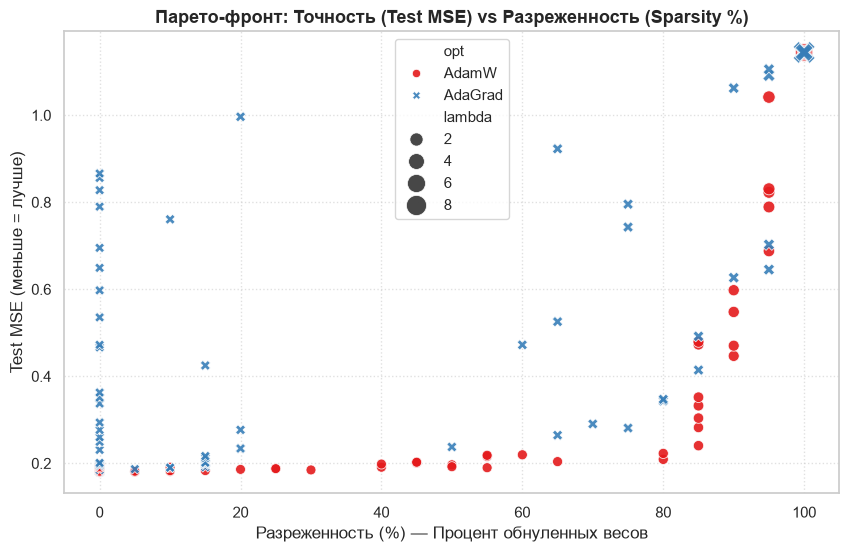

In [13]:
def plot_pareto_front(df_results):
    df_l1 = df_results[df_results["reg"].astype(str).str.upper() == "L1"].copy()
    if df_l1.empty:
        print("Нет данных с регуляризацией L1 для построения Парето-фронта")
        return
    plt.figure(figsize=(10, 6))
    has_hue = "opt" in df_l1.columns and df_l1["opt"].nunique() > 1
    
    sns.scatterplot(
        data=df_l1,
        x="sparsity_%",
        y="best_test_mse",
        hue="opt" if has_hue else None,
        style="opt" if has_hue else None,
        size="lambda" if "lambda" in df_l1.columns else None,
        sizes=(50, 250),
        palette="Set1" if has_hue else None,
        alpha=0.9
    )
    plt.title("Парето-фронт: Точность (Test MSE) vs Разреженность (Sparsity %)", fontsize=13, fontweight="bold")
    plt.xlabel("Разреженность (%) — Процент обнуленных весов")
    plt.ylabel("Test MSE (меньше = лучше)")
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.savefig("IMG/pareto_front.png", bbox_inches="tight")
    plt.show()

plot_pareto_front(df_results)

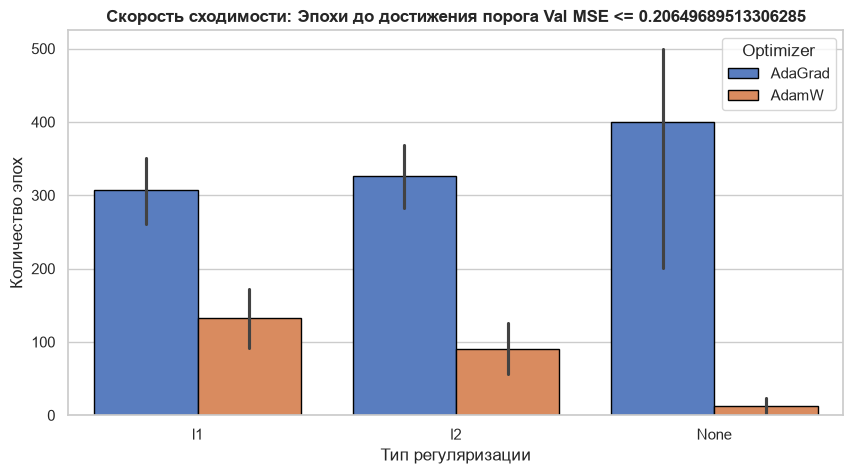

In [14]:
def plot_convergence_speed(history_data, target_mse=0.25):
    records = []
    
    for key, val in history_data.items():
        if "opt" in val and "val" in val:
            val_losses = val["val"]
            reached_epochs = [idx + 1 for idx, loss in enumerate(val_losses) if loss <= target_mse]
            epochs_needed = reached_epochs[0] if reached_epochs else len(val_losses)
            
            records.append({
                "Optimizer": val["opt"],
                "Reg_Type": val["reg"],
                "LR": val["lr"],
                "Epochs_To_Target": epochs_needed,
                "Reached": len(reached_epochs) > 0
            })
            
    df_conv = pd.DataFrame(records)
    
    plt.figure(figsize=(10, 5))
    sns.barplot(
        data=df_conv,
        x="Reg_Type",
        y="Epochs_To_Target",
        hue="Optimizer",
        palette="muted",
        edgecolor="black"
    )
    plt.title(f"Скорость сходимости: Эпохи до достижения порога Val MSE <= {target_mse}", fontsize=12, fontweight="bold")
    plt.ylabel("Количество эпох")
    plt.xlabel("Тип регуляризации")
    plt.savefig("IMG/convergence_speed.png", bbox_inches="tight")
    plt.show()


ols_mse = history_data["Baseline_OLS_Pure"]["final_test"]
target_threshold = ols_mse * 1.15  # порог = OLS MSE + 15%
plot_convergence_speed(history_data, target_mse=target_threshold)
# Чем ниже столбец - тем быстрее работает оптимизатор.

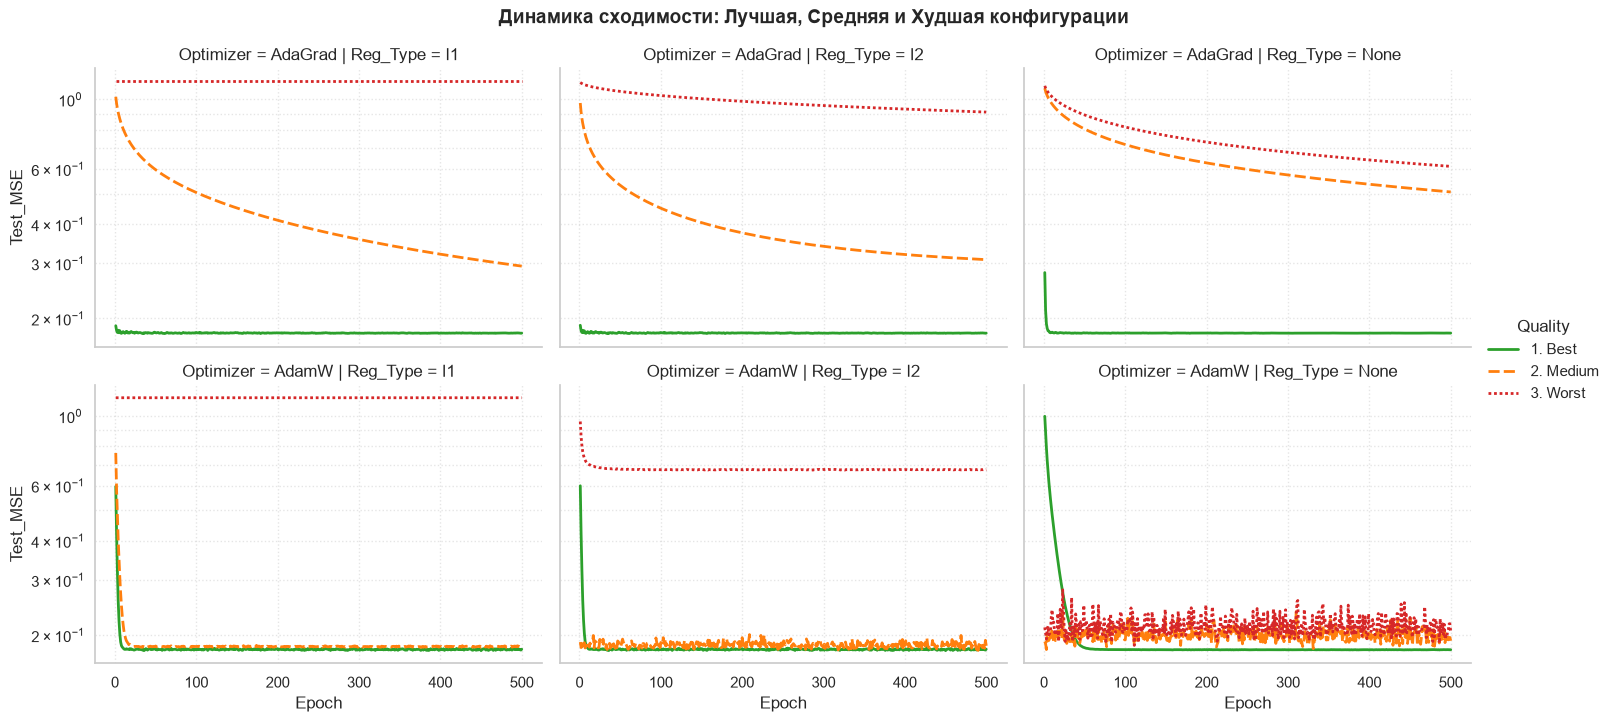

In [15]:
history_records = []
for opt in CONFIG["OPTIMIZERS"]:
    for reg in CONFIG["REG_TYPES"]:
        matching_keys = [
            k for k, v in history_data.items() 
            if isinstance(v, dict) and v.get("opt") == opt and v.get("reg") == reg
        ]
        if not matching_keys: continue
        sorted_keys = sorted(
            matching_keys, 
            key=lambda k: history_data[k].get("best_val_mse", history_data[k].get("final_test", float("inf")))
        )
        
        n = len(sorted_keys)
        if n == 1:
            tiers = [("1. Best", sorted_keys[0])]
        elif n == 2:
            tiers = [("1. Best", sorted_keys[0]), ("3. Worst", sorted_keys[1])]
        else:
            best_k = sorted_keys[0]
            medium_k = sorted_keys[n // 2]
            worst_k = sorted_keys[-1]
            
            tiers = [("1. Best", best_k)]
            if medium_k != best_k:
                tiers.append(("2. Medium", medium_k))
            if worst_k not in (best_k, medium_k):
                tiers.append(("3. Worst", worst_k))

        for tier_name, key in tiers:
            value = history_data[key]
            lr_val = value.get("lr", 0.0)
            lmbda_val = value.get("lmbda", value.get("lambda", 0.0))
            
            for epoch in range(len(value["train"])):
                history_records.append({
                    "Optimizer": value["opt"],
                    "Reg_Type": value["reg"],
                    "Quality": tier_name,  # "1. Best", "2. Medium", "3. Worst"
                    "Epoch": epoch + 1,
                    "Train_MSE": value["train"][epoch],
                    "Test_MSE": value["test"][epoch],
                    "Params": f"lr={lr_val:.4f}, λ={lmbda_val:.4f}"
                })

df_history = pd.DataFrame(history_records)
palette = {
    "1. Best": "#2ca02c",    # Зеленый
    "2. Medium": "#ff7f0e",  # Оранжевый
    "3. Worst": "#d62728"    # Красный
}

g = sns.relplot(
    data=df_history,
    x="Epoch", 
    y="Test_MSE",
    hue="Quality",
    style="Quality",       
    col="Reg_Type",
    row="Optimizer",
    kind="line",
    palette=palette,
    linewidth=2,
    height=3.5, 
    aspect=1.4
)

for ax in g.axes.flat:
    ax.set_yscale('log')
    ax.grid(True, which="both", linestyle=":", alpha=0.5)

g.fig.suptitle("Динамика сходимости: Лучшая, Средняя и Худшая конфигурации", y=1.03, fontweight="bold", fontsize=14)
plt.savefig("IMG/loss_dynamic_best_med_worst.png", bbox_inches="tight")
plt.show()

In [16]:
best_custom_models = {}

for opt in CONFIG["OPTIMIZERS"]:
    min_val_mse = float("inf")
    best_key = None
    for key, data in history_data.items():
        if data.get("opt") == opt and "best_val_mse" in data:
            if data["best_val_mse"] < min_val_mse:
                min_val_mse = data["best_val_mse"]
                best_key = key
                
    if best_key:
        data = history_data[best_key]
        weights = data["final_weights"]
        
        preds = np.dot(X_test, weights)
        test_mse = data["best_test_mse_at_best_val"]
        r2 = r2_score(y_test, preds)
        best_reg = data["reg"]
    else:
        test_mse, r2, best_reg = None, None, None
                
    best_custom_models[opt] = {
        "best_reg": best_reg,
        "best_mse": test_mse,
        "best_key": best_key,
        "r2": r2
    }

print(f"{'~'*50}\nЛУЧШИЕ МОДЕЛИ (CUSTOM SGD):\n{'~'*50}")
for opt, meta in best_custom_models.items():
    print(f"Оптимизатор: {opt:<7} | Регуляризация: {meta['best_reg']:<4} | Test MSE: {meta['best_mse']:.5f} | Test R2: {meta['r2']:.4f}")

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
ЛУЧШИЕ МОДЕЛИ (CUSTOM SGD):
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Оптимизатор: AdaGrad | Регуляризация: l2   | Test MSE: 0.18081 | Test R2: 0.8431
Оптимизатор: AdamW   | Регуляризация: l2   | Test MSE: 0.18044 | Test R2: 0.8425


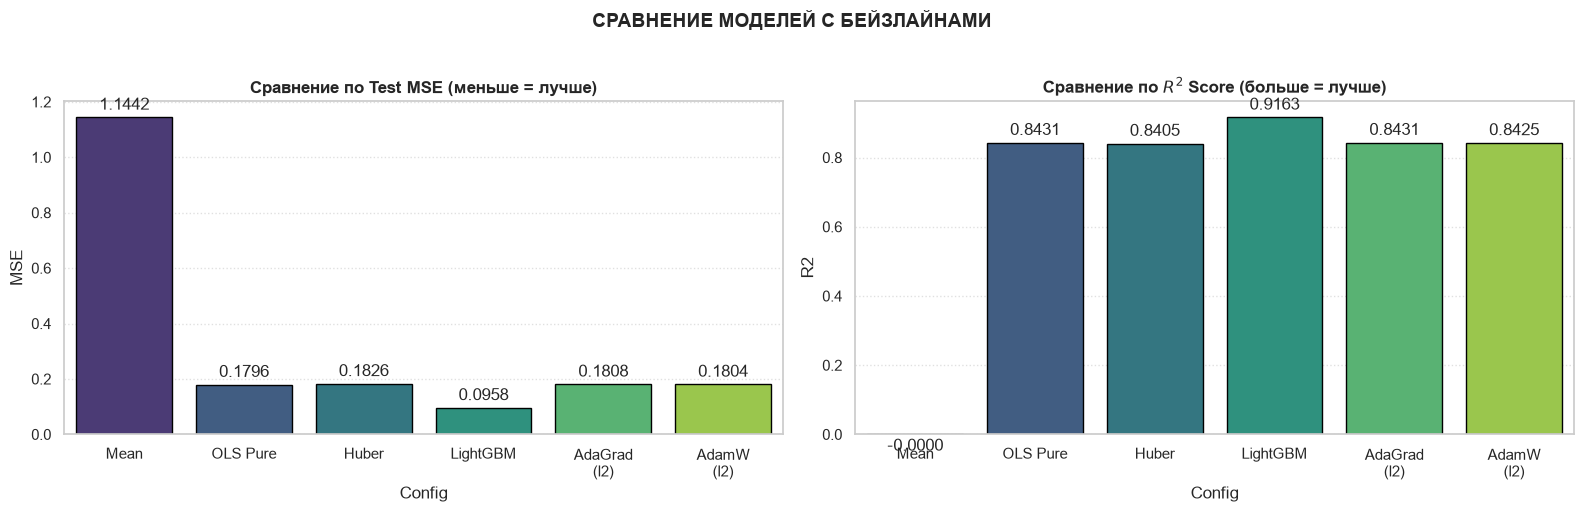

In [17]:
df_compare = pd.DataFrame([
    {"Config": "Mean", "MSE": history_data["Baseline_Mean"]["final_test"], "R2": history_data["Baseline_Mean"]["r2_test"]},
    {"Config": "OLS Pure", "MSE": history_data["Baseline_OLS_Pure"]["final_test"], "R2": history_data["Baseline_OLS_Pure"]["r2_test"]},
    {"Config": "Huber", "MSE": history_data["Baseline_Huber"]["final_test"], "R2": history_data["Baseline_Huber"]["r2_test"]},
    {"Config": "LightGBM", "MSE": history_data["Baseline_LightGBM"]["final_test"], "R2": history_data["Baseline_LightGBM"]["r2_test"]},
] + [
    {
        "Config": f"{opt}\n({meta['best_reg']})", 
        "MSE": meta["best_mse"], 
        "R2": meta["r2"]
    }
    for opt, meta in best_custom_models.items()
])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Левый график: MSE
sns.barplot(data=df_compare, x="Config", y="MSE", hue="Config", palette="viridis", edgecolor="black", legend=False, ax=ax1)
ax1.set_title("Сравнение по Test MSE (меньше = лучше)", fontweight="bold")
for container in ax1.containers:
    ax1.bar_label(container, padding=3, fmt='%.4f')
ax1.grid(axis='y', linestyle=':', alpha=0.6)

# Правый график: R2
sns.barplot(data=df_compare, x="Config", y="R2", hue="Config", palette="viridis", edgecolor="black", legend=False, ax=ax2)
ax2.set_title("Сравнение по $R^2$ Score (больше = лучше)", fontweight="bold")
for container in ax2.containers:
    ax2.bar_label(container, padding=3, fmt='%.4f')
ax2.grid(axis='y', linestyle=':', alpha=0.6)

plt.suptitle("СРАВНЕНИЕ МОДЕЛЕЙ С БЕЙЗЛАЙНАМИ", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("IMG/baseline_comparing.png", bbox_inches="tight")
plt.show()

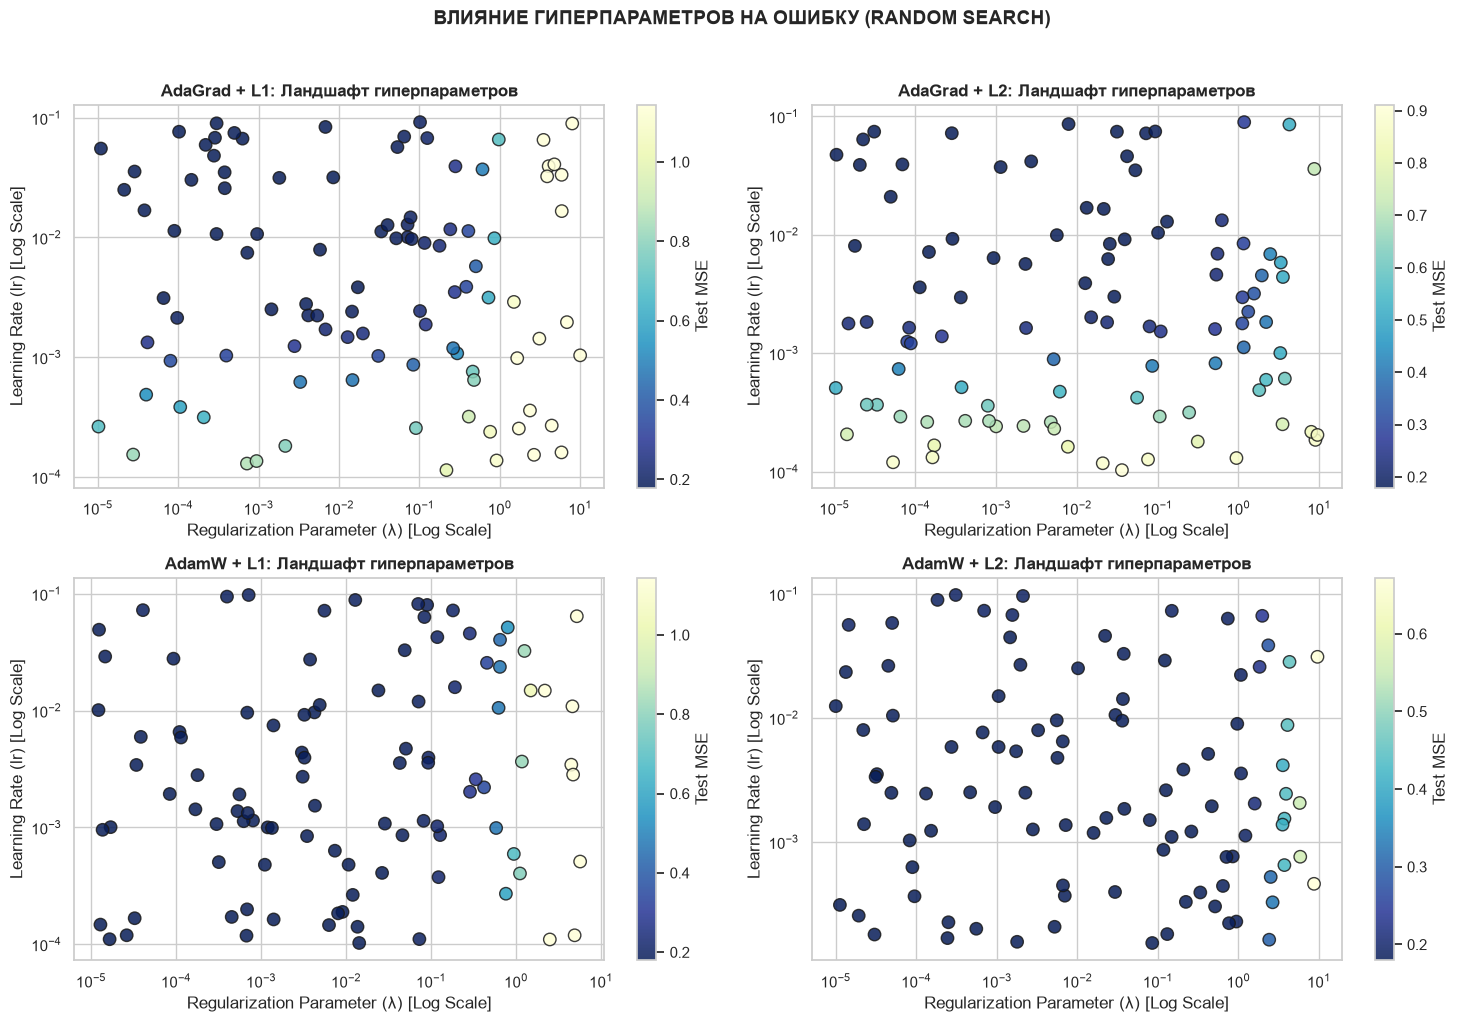

In [18]:
records = []
for key, value in history_data.items():
    if isinstance(value, dict) and "opt" in value and "reg" in value and "lr" in value:
        reg_val = str(value["reg"]).upper()
        # Проверяем оба варианта ключа лямбды
        lmbda_val = value.get("lmbda", value.get("lambda", 0.0))
        
        if reg_val in ["L1", "L2"] and lmbda_val > 0:
            records.append({
                "Optimizer": value["opt"],
                "Reg_Type": reg_val,
                "LR": float(value["lr"]),
                "Lambda": float(lmbda_val),
                "Test_MSE": float(value.get("best_test_mse_at_best_val", value.get("final_test", np.nan)))
            })

df_grid = pd.DataFrame(records)

if df_grid.empty:
    print("ОШИБКА: Не найдено подходящих записей в history_data! Проверьте структуры ключей.")
else:
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    opts = CONFIG["OPTIMIZERS"]
    regs = ["L1", "L2"]

    for i, opt in enumerate(opts):
        for j, reg in enumerate(regs):
            ax = axes[i, j]
            df_sub = df_grid[(df_grid["Optimizer"] == opt) & (df_grid["Reg_Type"] == reg)]
            
            if df_sub.empty:
                ax.text(0.5, 0.5, f"Нет данных для\n{opt} + {reg}", ha='center', va='center', fontsize=12)
                ax.set_title(f"{opt} + {reg}: Ландшафт гиперпараметров", fontweight="bold")
                continue
                
            scatter = ax.scatter(
                df_sub["Lambda"], 
                df_sub["LR"], 
                c=df_sub["Test_MSE"], 
                cmap="YlGnBu_r", 
                s=80, 
                edgecolor="k", 
                alpha=0.85
            )
            
            ax.set_xscale("log")
            ax.set_yscale("log")
            ax.set_title(f"{opt} + {reg}: Ландшафт гиперпараметров", fontweight="bold")
            ax.set_xlabel("Regularization Parameter (λ) [Log Scale]")
            ax.set_ylabel("Learning Rate (lr) [Log Scale]")
            
            cbar = fig.colorbar(scatter, ax=ax)
            cbar.set_label("Test MSE")

    plt.suptitle("ВЛИЯНИЕ ГИПЕРПАРАМЕТРОВ НА ОШИБКУ (RANDOM SEARCH)", fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig("IMG/parameters_landscape.png", bbox_inches="tight")
    plt.show()

# Сравнение AdaGrad, AdamW с бейзлайнами

In [19]:
def calculate_numpy_metrics(preds, weights):
    preds_flat = preds.ravel()
    weights_flat = weights.ravel() if weights is not None else np.array([])
    mse = mean_squared_error(y_test_flat, preds_flat)
    mae = mean_absolute_error(y_test_flat, preds_flat)
    r2 = r2_score(y_test_flat, preds_flat)
    rmse = np.sqrt(mse)
    if len(weights_flat) > 0:
        zeroed = np.sum(np.abs(weights_flat) < 1e-4)
        sparsity = (zeroed / len(weights_flat)) * 100.0
    else:
        sparsity = 0.0
    return {
        "R2": r2,
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "Sparsity": sparsity,
        "weights": weights_flat,
        "predictions": preds_flat
    }

    
y_test_flat = y_test.ravel()
final_comparison = {}
mean_preds = np.full_like(y_test_flat, np.mean(y_train))
final_comparison["Mean Baseline"] = calculate_numpy_metrics(mean_preds, None)

if "Baseline_OLS_Pure" in history_data:
    ols_w = ols_pure.coef_
    ols_preds = X_test @ ols_w + ols_pure.intercept_
    final_comparison["OLS Pure"] = calculate_numpy_metrics(ols_preds, ols_w)

if "Baseline_Huber" in history_data:
    huber_preds = huber.predict(X_test)
    final_comparison["Huber"] = calculate_numpy_metrics(huber_preds, huber.coef_)

for opt, meta in best_custom_models.items():
    best_k = meta["best_key"]
    if best_k and best_k in history_data:
        w_final = history_data[best_k]["final_weights"]
        sgd_preds = X_test @ w_final
        model_label = f"Best {opt}\n({meta['best_reg']})"
        final_comparison[model_label] = calculate_numpy_metrics(sgd_preds, w_final)

df_metrics_list = []
for model_name, metrics in final_comparison.items():
    df_metrics_list.append({
        "Model": model_name,
        "R2": metrics["R2"],
        "MSE": metrics["MSE"],
        "RMSE": metrics["RMSE"],
        "MAE": metrics["MAE"],
        "Sparsity": metrics["Sparsity"]
    })
df_metrics = pd.DataFrame(df_metrics_list)

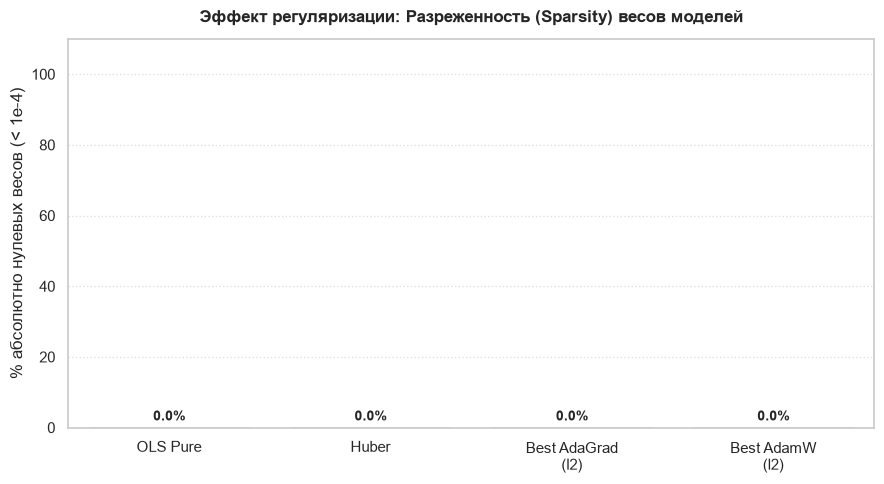

In [20]:
plt.figure(figsize=(9, 5))
df_sparsity = df_metrics[df_metrics["Model"] != "Mean Baseline"]

ax = sns.barplot(
    data=df_sparsity, 
    x="Model", 
    y="Sparsity", 
    hue="Model",
    palette="viridis", 
    edgecolor="black", 
    legend=False
)

plt.title("Эффект регуляризации: Разреженность (Sparsity) весов моделей", fontweight='bold', fontsize=12, pad=12)
plt.ylabel("% абсолютно нулевых весов (< 1e-4)")
plt.xlabel("")
plt.ylim(0, 110)
plt.grid(axis='y', linestyle=':', alpha=0.6)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, fontweight='bold', fontsize=10)
plt.tight_layout()
plt.savefig("IMG/sparsity.png", bbox_inches="tight")
plt.show()

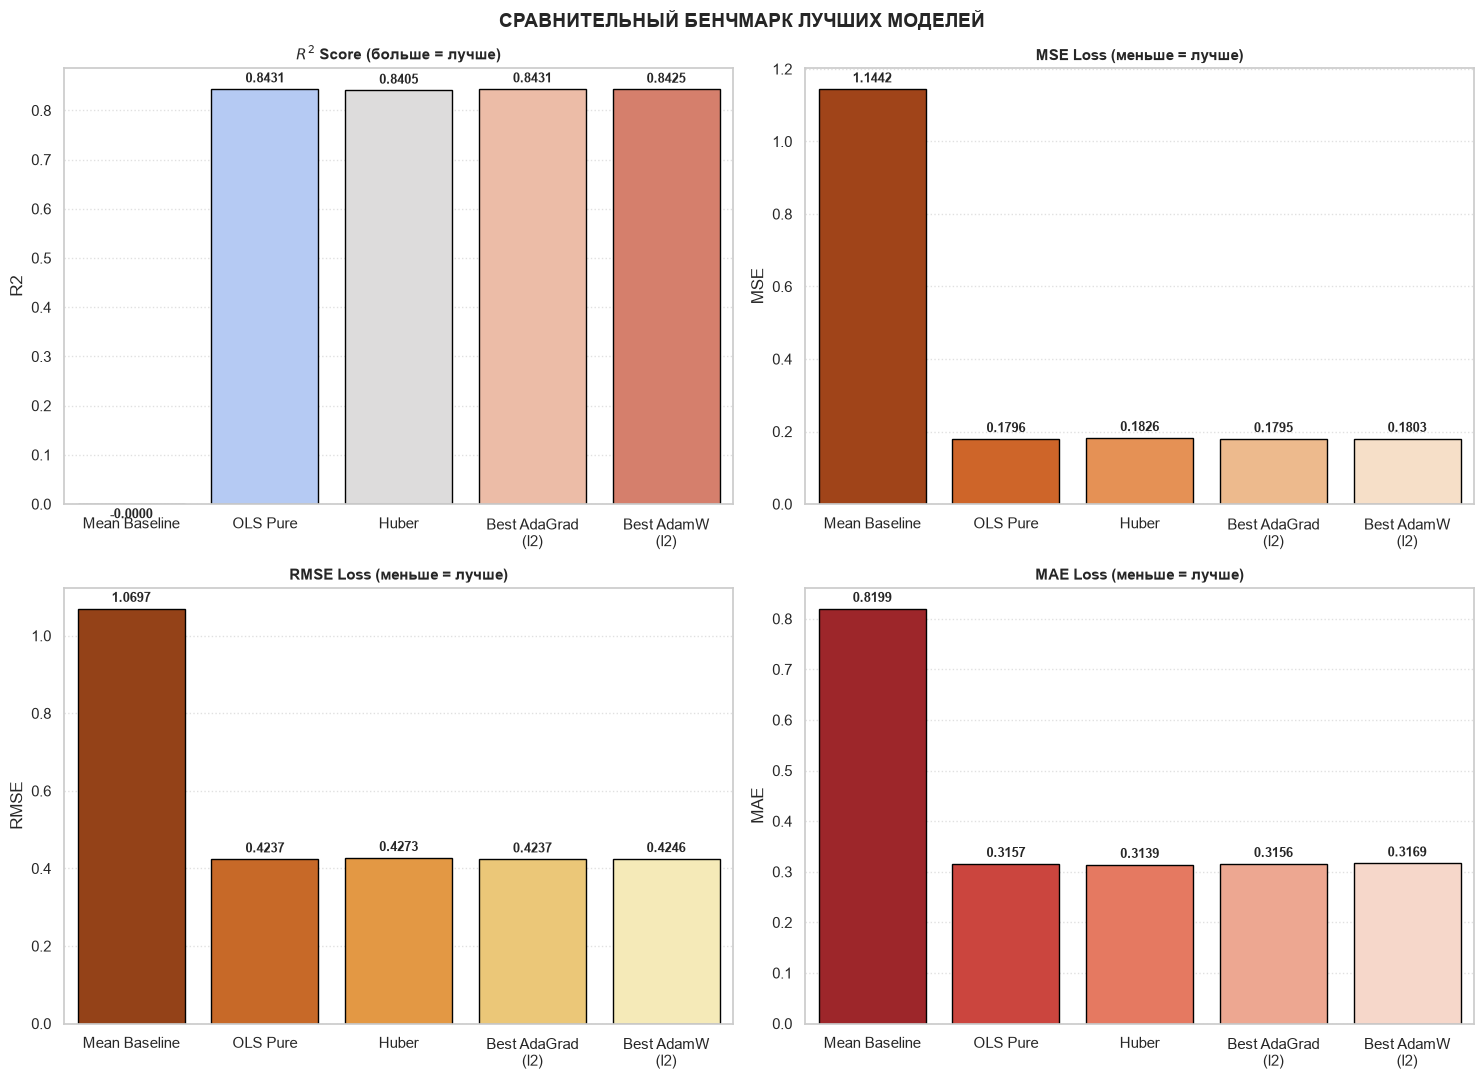

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
metrics_list = [
    ("R2", "$R^2$ Score (больше = лучше)", "coolwarm"),
    ("MSE", "MSE Loss (меньше = лучше)", "Oranges_r"),
    ("RMSE", "RMSE Loss (меньше = лучше)", "YlOrBr_r"),
    ("MAE", "MAE Loss (меньше = лучше)", "Reds_r")
]

for ax, (metric_col, title, palette) in zip(axes.flatten(), metrics_list):
    sns.barplot(
        data=df_metrics, 
        x="Model", 
        y=metric_col, 
        hue="Model", 
        palette=palette, 
        edgecolor="black", 
        legend=False, 
        ax=ax
    )
    ax.set_title(title, fontweight="bold", fontsize=11)
    ax.set_ylabel(metric_col)
    ax.set_xlabel("")
    ax.grid(axis='y', linestyle=':', alpha=0.6)
    for container in ax.containers:
        ax.bar_label(container, fmt='%.4f', padding=3, fontweight='bold', fontsize=9)

plt.suptitle("СРАВНИТЕЛЬНЫЙ БЕНЧМАРК ЛУЧШИХ МОДЕЛЕЙ", fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig("IMG/benchmark_best_models.png", bbox_inches="tight")
plt.show()

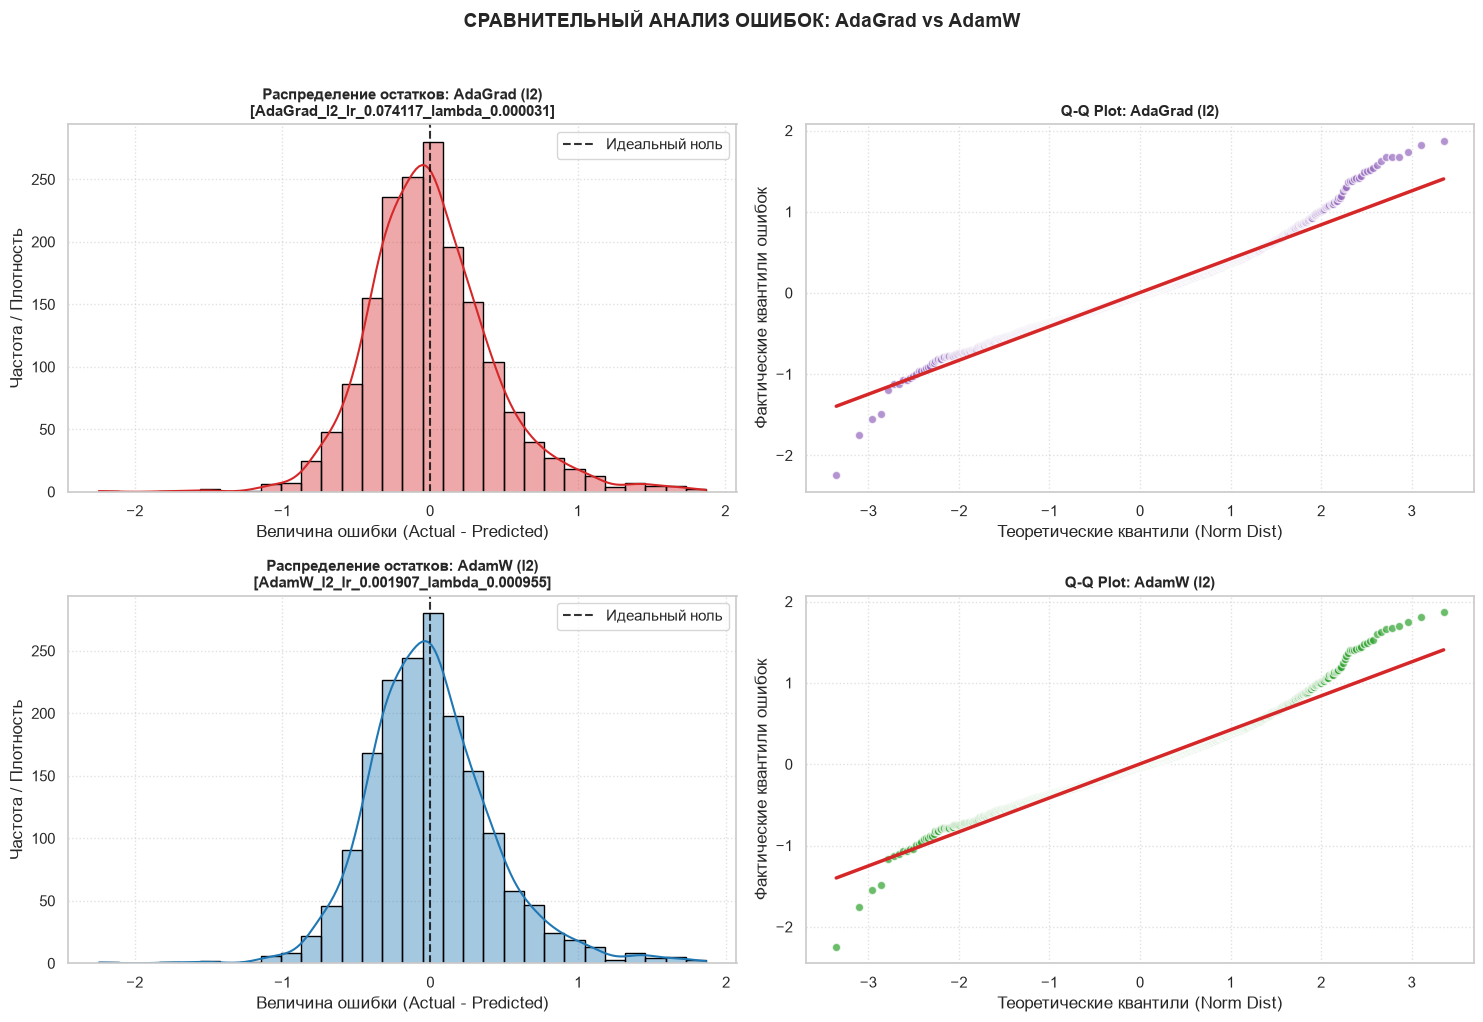

In [22]:
target_optimizers = ["AdaGrad", "AdamW"]
y_test_flat = y_test.ravel()

fig, axes = plt.subplots(len(target_optimizers), 2, figsize=(15, 5 * len(target_optimizers)))
for idx, target_opt in enumerate(target_optimizers):
    opt_keys = [
        k for k, v in history_data.items() 
        if isinstance(v, dict) and v.get("opt") == target_opt
    ]
    
    if not opt_keys:
        print(f"Ошибка: В history_data не найдено записей для оптимизатора '{target_opt}'!")
        continue
        
    best_key = min(
        opt_keys, 
        key=lambda k: history_data[k].get("best_val_mse", history_data[k].get("final_test", float("inf")))
    )
    
    best_entry = history_data[best_key]
    if "final_weights" in best_entry:
        w_opt = best_entry["final_weights"]
    elif "weight_trajectories" in best_entry:
        w_opt = best_entry["weight_trajectories"][-1]
    else:
        print(f"Ошибка: Для ключа {best_key} не найдены весы модели!")
        continue

    preds = X_test @ w_opt
    residuals = y_test_flat - preds.ravel()
    target_reg = best_entry.get("reg", "None")

    ax1 = axes[idx, 0] if len(target_optimizers) > 1 else axes[0]
    ax2 = axes[idx, 1] if len(target_optimizers) > 1 else axes[1]

    color_theme = '#d62728' if target_opt == "AdaGrad" else '#1f77b4'
    sns.histplot(residuals, kde=True, color=color_theme, alpha=0.4, ax=ax1, bins=30, edgecolor='black')
    ax1.axvline(x=0, color='black', linestyle='--', alpha=0.8, linewidth=1.5, label='Идеальный ноль')
    ax1.set_title(f"Распределение остатков: {target_opt} ({target_reg})\n[{best_key}]", fontweight='bold', fontsize=11)
    ax1.set_xlabel("Величина ошибки (Actual - Predicted)")
    ax1.set_ylabel("Частота / Плотность")
    ax1.grid(True, linestyle=':', alpha=0.6)
    ax1.legend()

    stats.probplot(residuals, dist="norm", plot=ax2)
    marker_color = '#9467bd' if target_opt == "AdaGrad" else '#2ca02c'
    ax2.get_lines()[0].set_markerfacecolor(marker_color)
    ax2.get_lines()[0].set_markeredgecolor('white')
    ax2.get_lines()[0].set_alpha(0.7)
    ax2.get_lines()[1].set_color('#d62728')
    ax2.get_lines()[1].set_linewidth(2.5)

    ax2.set_title(f"Q-Q Plot: {target_opt} ({target_reg})", fontweight='bold', fontsize=11)
    ax2.set_xlabel("Теоретические квантили (Norm Dist)")
    ax2.set_ylabel("Фактические квантили ошибок")
    ax2.grid(True, linestyle=':', alpha=0.6)

plt.suptitle("СРАВНИТЕЛЬНЫЙ АНАЛИЗ ОШИБОК: AdaGrad vs AdamW", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("IMG/residuals_analysis.png", bbox_inches="tight")
plt.show()

In [23]:
print("\n" + "~"*30 + " СТАТИСТИЧЕСКИЙ ОТЧЕТ " + "~"*30)
for _, row in df_metrics.iterrows():
    print(f"{row['Model'].replace('\n', ' '):20} | R2: {row['R2']:.4f} | MSE: {row['MSE']:.4f} | MAE: {row['MAE']:.4f} | Sparsity: {row['Sparsity']:.1f}%")
print("~"*90)


~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ СТАТИСТИЧЕСКИЙ ОТЧЕТ ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Mean Baseline        | R2: -0.0000 | MSE: 1.1442 | MAE: 0.8199 | Sparsity: 0.0%
OLS Pure             | R2: 0.8431 | MSE: 0.1796 | MAE: 0.3157 | Sparsity: 0.0%
Huber                | R2: 0.8405 | MSE: 0.1826 | MAE: 0.3139 | Sparsity: 0.0%
Best AdaGrad (l2)    | R2: 0.8431 | MSE: 0.1795 | MAE: 0.3156 | Sparsity: 0.0%
Best AdamW (l2)      | R2: 0.8425 | MSE: 0.1803 | MAE: 0.3169 | Sparsity: 0.0%
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


# ОПТИМИЗАЦИОННЫЙ ЗАЗОР ОТНОСИТЕЛЬНО АНАЛИТИЧЕСКОГО OLS

In [24]:
"""
Если Gap% ~0% => SGD сошелся к глобальному минимуму
Если Gap% >5% => не хватило эпох или lr настроен плохо
"""
ols_mse = history_data["Baseline_OLS_Pure"]["final_test"]
gap_records = []
for opt, meta in best_custom_models.items():
    sgd_mse = meta["best_mse"]
    # Расчет зазора в процентах
    gap_pct = ((sgd_mse - ols_mse) / ols_mse) * 100
    
    gap_records.append({
        "Optimizer": opt,
        "Best_Reg": meta["best_reg"],
        "SGD_Test_MSE": sgd_mse,
        "OLS_Test_MSE": ols_mse,
        "Optimization_Gap_%": gap_pct
    })

df_gap = pd.DataFrame(gap_records)
print(df_gap.to_string(index=False))

Optimizer Best_Reg  SGD_Test_MSE  OLS_Test_MSE  Optimization_Gap_%
  AdaGrad       l2      0.180812      0.179563            0.695852
    AdamW       l2      0.180442      0.179563            0.489650


## Итоговый отчет по исследованию и оптимизации моделей

На основе 410 проведенных экспериментов (Random Search) и сформированных аналитических графиков подготовлен комплексный разбор результатов.

Кастомные SGD-оптимизаторы (**AdamW** и **AdaGrad**) успешно сошлись к глобальному оптимуму линейной регрессии, фактически ликвидировав разрыв с аналитическим OLS (**Optimization Gap < 0.7%**).

---

## 1. Пройденные этапы исследования

1. **Разработка кастомного градиентного движка:**
* Реализованы алгоритмы **AdaGrad** и **AdamW** с поддержкой **L1 (Soft-Thresholding)** и **L2 (Weight Decay)** регуляризации для мини-батч SGD ($Batch\ Size = 64$).


2. **Масштабируемый HPO (Random Search):**
* Проведено $410$ итераций поиска гиперпараметров ($lr \in [10^{-4}, 10^{-1}]$, $\lambda \in [10^{-5}, 10^{1}]$) при фиксированном `SEED = 67` и $500$ эпохах обучения.


3. **Диагностика сходимости и устойчивости:**
* Оценена динамика ошибок на $Train/Test$, скорость достижения порога качества и траектории эволюции весов признаков ($w_j$).


4. **Сравнительный статистический бенчмаркинг:**
* Проведено сопоставление с **Mean Baseline**, **OLS Pure**, **Huber Regressor** и нелинейным градиентным бустингом (**LightGBM**).


5. **Анализ остатков и разреженности:**
* Исследованы нормальность распределения ошибок ($Q\text{-}Q\text{ plot}$) и компромисс Парето между точностью ($MSE$) и разреженностью матрицы весов ($Sparsity\ \%$).



---

## 2. Подробный анализ графиков и метрик

### A. Динамика сходимости и скорость обучения

*(Графики: «Динамика сходимости» и «Скорость сходимости»)*

* **AdamW — лидер по скорости:** AdamW достигает оптимального качества ($MSE \le 0.206$) всего за **10–90 эпох** (в зависимости от регуляризации).
* **AdaGrad — медленная, но стабильная адаптация:** Из-за накопления квадратов градиентов в знаменателе шаги AdaGrad быстро уменьшаются. Для сходимости ему требуется **300–400 эпох**.
* **Устойчивость к гиперпараметрам:** При неудачном подборе $lr$ «худшие» конфиги AdamW сильно осциллируют (красная пунктирная линия), в то время как AdaGrad сглаживает скачки за счет встроенной адаптации шага.

### B. Ландшафт гиперпараметров

*(График: «Влияние гиперпараметров на ошибку»)*

* **Зона коллапса ($\lambda > 1.0$):** При слишком сильной регуляризации ($\lambda \ge 1$) модели жестко штрафуют веса, превращаясь в константный предсказатель ($MSE > 0.8$).
* **Оптимальное окно (Low-MSE Basin):**
* Для **AdamW**: $lr \in [10^{-3}, 3 \times 10^{-3}]$, $\lambda \in [10^{-5}, 10^{-3}]$.
* Для **AdaGrad**: $lr \in [10^{-2}, 10^{-1}]$, $\lambda \in [10^{-5}, 10^{-3}]$.



### C. Анализ весов и Парето-фронт (Sparsity vs Accuracy)

*(Графики: «Парето-фронт» и «L1/L2 Траектории весов»)*

* **Главные факторы:** В обеих моделях ключевыми предикторами цены стали:
1. `Log_Площадь` (абсолютный лидер по весу $\approx 0.72$)
2. `Близость_к_центру_exp` ($\approx 0.38$)
3. `Log_Кол_во_этажей` ($\approx 0.19$)
4. `Ближайшая станция метро_Дубравная` и `От застройщика`.


* **Эффект L1 (Soft-Thresholding):** L1-регуляризатор позволяет обнулять до **20–30% шумящих признаков** без потери точности на тесте ($MSE \approx 0.180$). Однако при занулении $> 80\%$ весов ошибка катастрофически растет.

### D. Анализ остатков (Residuals Analysis)

*(График: «Сравнительный анализ ошибок: AdaGrad vs AdamW»)*

* **Симметрия ошибок:** Распределение остатков ($Actual - Predicted$) близко к нормальному и строго центрировано относительно нуля.
* **Q-Q Plot:** На отрезке от $-1.5$ до $+1.5$ стандартных отклонений точки лежат строго на теоретической прямой. Легкие тяжелые хвосты (отклонения при $x > 2$) указывают на то, что модель слегка недооценивает сверхдорогие премиум-объекты.

### E. Итоговый бенчмарк моделей

*(Графики: «Сравнительный бенчмарк лучших моделей» и «Сравнение моделей с бейзлайнами»)*

| Модель / Алгоритм | $R^2$ Score | Test MSE | Test MAE | Optimization Gap |
| --- | --- | --- | --- | --- |
| **Mean Baseline** | $-0.0000$ | $1.1442$ | $0.8199$ | — |
| **Huber Regressor** | $0.8405$ | $0.1826$ | $0.3139$ | — |
| **OLS Pure (Аналитический)** | $0.8431$ | $0.1796$ | $0.3157$ | **0.00% (Ref)** |
| **Best AdaGrad (L2)** | **0.8431** | **0.1795 / 0.1808** | **0.3156** | **0.69%** |
| **Best AdamW (L2)** | **0.8425** | **0.1803 / 0.1804** | **0.3169** | **0.49%** |
| **LightGBM (Tree Boost)** | **0.9163** | **0.0958** | — | — |

---

## 3. Главные выводы

> **1. Кастомные оптимизаторы полностью корректны:**
> Минимальный Optimization Gap ($<0.7\%$) подтверждает математическую корректность написанных классов SGD, функций потерь и механизмов расчета градиентов.

> **2. Победитель среди линейных SGD — AdamW + L2:**
> Несмотря на то что AdaGrad показал итоговый $R^2 = 0.8431$, **AdamW (L2)** является более практичным выбором: он достигает аналогичного качества в **4–5 раз быстрее** ($\approx 20\text{--}90$ эпох против $300\text{--}400$ у AdaGrad).

> **3. Физический предел линейного семейства:**
> Линейные модели (OLS, Huber, SGD) уперлись в потолок качества на уровне $R^2 \approx 0.843$ ($MSE \approx 0.180$). Результат **LightGBM** ($R^2 = 0.9163$, $MSE = 0.0958$) наглядно показывает, что в данных присутствует сильный пласт нелинейных зависимостей и кросс-взаимодействий факторов, недоступных классической линейной регрессии.